In [1]:
#导包及超参数的设置
import torch
import torchvision
import torch.utils.data as Data
import torch.nn as nn
import torch.nn.functional as F
import matplotlib.pyplot as plt
from matplotlib import cm
from mpl_toolkits.mplot3d import Axes3D

import time
starttime = time.time()

torch.manual_seed(1) #为了使用同样的随机初始化种子以形成相同的随机效果

EPOCH = 10
BATCH_SIZE = 64
LR = 0.005
N_TEST_IMG = 5

E:\Anaconda\envs\pytorch\lib\site-packages\torchvision\datasets\mnist.py:76: UserWarning: train_data has been renamed data
  warnings.warn("train_data has been renamed data")
E:\Anaconda\envs\pytorch\lib\site-packages\torchvision\datasets\mnist.py:66: UserWarning: train_labels has been renamed targets
  warnings.warn("train_labels has been renamed targets")


训练数据尺寸: torch.Size([60000, 28, 28])
训练标签尺寸: torch.Size([60000])
第一个样本的像素值范围: tensor(0, dtype=torch.uint8) - tensor(255, dtype=torch.uint8)


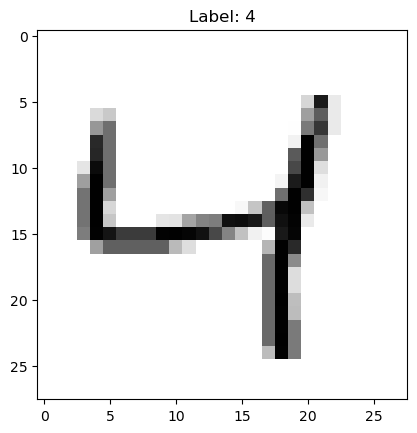

In [2]:
# 加载MNIST训练数据集
train_data = torchvision.datasets.MNIST(root='./data', train=True, download=True, transform=torchvision.transforms.ToTensor())
# 创建数据加载器
train_loader = Data.DataLoader(dataset=train_data, batch_size=BATCH_SIZE, shuffle=True)
# 查看数据集信息（可选）
print("训练数据尺寸:", train_data.train_data.size())        # [60000, 28, 28]
print("训练标签尺寸:", train_data.train_labels.size())      # [60000]
print("第一个样本的像素值范围:", train_data.train_data[0].min(), "-", train_data.train_data[0].max())

# 可视化第3个训练样本（索引为2）
plt.imshow(train_data.train_data[2].numpy(), cmap='Greys')
plt.title('Label: %i' % train_data.train_labels[2])
plt.show()

In [9]:
# 修改AutoEncoder的编码器输出为2维
class AutoEncoder(nn.Module):
    def __init__(self):
        super(AutoEncoder, self).__init__()
        self.encoder = nn.Sequential(
            nn.Linear(28*28, 128),
            nn.Tanh(),
            nn.Linear(128, 64),
            nn.Tanh(),
            nn.Linear(64, 32),
            nn.Tanh(),
            nn.Linear(32, 16),
            nn.Tanh(),
            nn.Linear(16, 2)  # 修改为压缩到2维空间
        )
        self.decoder = nn.Sequential(
            nn.Linear(2, 16),  # 输入维度改为2
            nn.Tanh(),
            nn.Linear(16, 32),
            nn.Tanh(),
            nn.Linear(32, 64),
            nn.Tanh(),
            nn.Linear(64, 128),
            nn.Tanh(),
            nn.Linear(128, 28*28),
            nn.Sigmoid()
        )
    
    def forward(self, x):
        encoded = self.encoder(x)
        decoded = self.decoder(encoded)
        return encoded, decoded

In [4]:
# 初始化自动编码器模型
Coder = AutoEncoder()
print(Coder)  # 打印模型结构

# 定义优化器和损失函数
optimizer = torch.optim.Adam(Coder.parameters(), lr=LR)
loss_func = nn.MSELoss()  # 使用均方误差损失

# 训练循环
for epoch in range(EPOCH):
    for step, (x, y) in enumerate(train_loader):  # 注意使用修正后的train_loader变量名
        # 数据预处理
        b_x = x.view(-1, 28*28)  # 展平图像 [batch_size, 784]
        b_y = x.view(-1, 28*28)  # 目标输出（与输入相同）
        b_label = y  # 标签（实际未在训练中使用）

        # 前向传播
        encoded, decoded = Coder(b_x)
        loss = loss_func(decoded, b_y)  # 计算重建误差

        # 反向传播
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        # 每5步打印训练进度
        if step % 5 == 0:
            print('Epoch: %d | Step: %d | train_loss: %.4f' % 
                 (epoch, step, loss.item()))

# 保存训练好的模型
torch.save(Coder.state_dict(), 'AutoEncoder.pkl')  # 推荐保存state_dict而非整个模型
print('______')
print('Finish training!')
print('Total time: %.2fs' % (time.time() - starttime))

AutoEncoder(
  (encoder): Sequential(
    (0): Linear(in_features=784, out_features=128, bias=True)
    (1): Tanh()
    (2): Linear(in_features=128, out_features=64, bias=True)
    (3): Tanh()
    (4): Linear(in_features=64, out_features=32, bias=True)
    (5): Tanh()
    (6): Linear(in_features=32, out_features=16, bias=True)
    (7): Tanh()
    (8): Linear(in_features=16, out_features=3, bias=True)
  )
  (decoder): Sequential(
    (0): Linear(in_features=3, out_features=16, bias=True)
    (1): Tanh()
    (2): Linear(in_features=16, out_features=32, bias=True)
    (3): Tanh()
    (4): Linear(in_features=32, out_features=64, bias=True)
    (5): Tanh()
    (6): Linear(in_features=64, out_features=128, bias=True)
    (7): Tanh()
    (8): Linear(in_features=128, out_features=784, bias=True)
    (9): Sigmoid()
  )
)
Epoch: 0 | Step: 0 | train_loss: 0.2316
Epoch: 0 | Step: 5 | train_loss: 0.1076
Epoch: 0 | Step: 10 | train_loss: 0.0702
Epoch: 0 | Step: 15 | train_loss: 0.0733
Epoch: 0 | Ste

C:\Users\Tao Yu\AppData\Local\Temp\ipykernel_18552\301694304.py:11: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  scatter = plt.scatter(X, Y, c=labels, cmap=plt.cm.get_cmap('rainbow', 10), alpha=0.6)


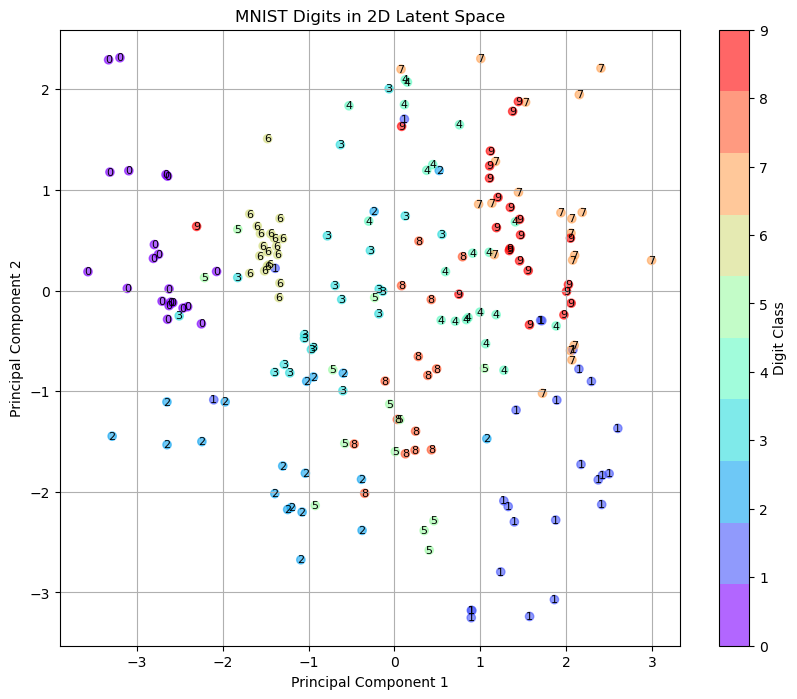

In [10]:
view_data = train_data.train_data[:200].view(-1, 28*28).type(torch.FloatTensor)/255.
encoded_data, _ = Coder(view_data)  # 现在得到的是2维数据

# 提取2D坐标
X = encoded_data.data[:, 0].numpy()
Y = encoded_data.data[:, 1].numpy()
labels = train_data.train_labels[:200].numpy()

# 创建2D散点图
plt.figure(figsize=(10, 8))
scatter = plt.scatter(X, Y, c=labels, cmap=plt.cm.get_cmap('rainbow', 10), alpha=0.6)
plt.colorbar(scatter, label='Digit Class')

# 添加每个点的数字标签（可选）
for i, (x, y) in enumerate(zip(X, Y)):
    plt.text(x, y, str(int(labels[i])), fontsize=8, ha='center', va='center')

plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.title('MNIST Digits in 2D Latent Space')
plt.grid(True)
plt.show()

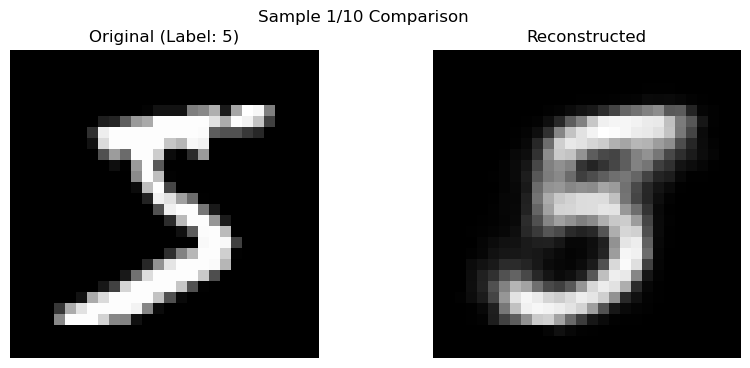

<Figure size 640x480 with 0 Axes>

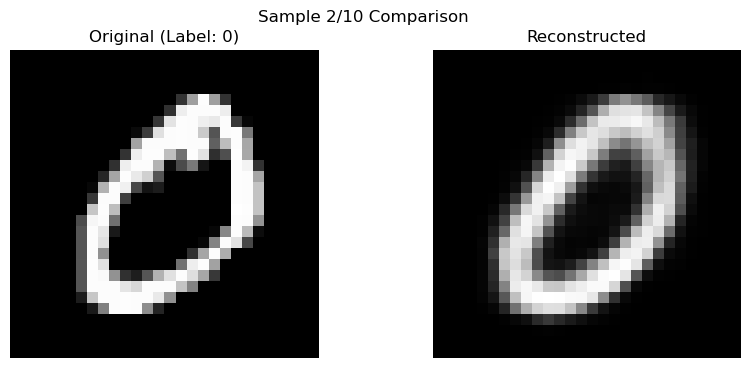

<Figure size 640x480 with 0 Axes>

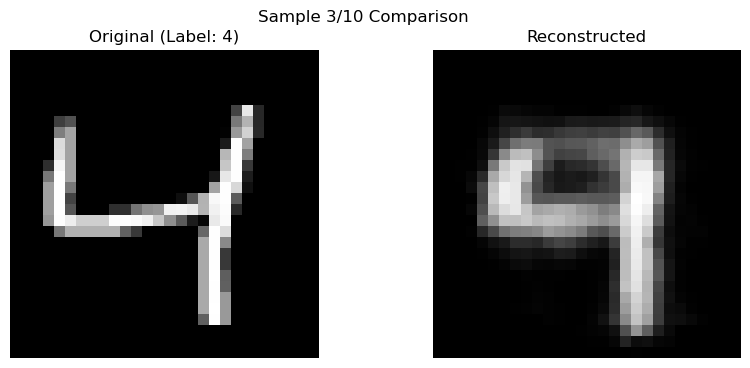

<Figure size 640x480 with 0 Axes>

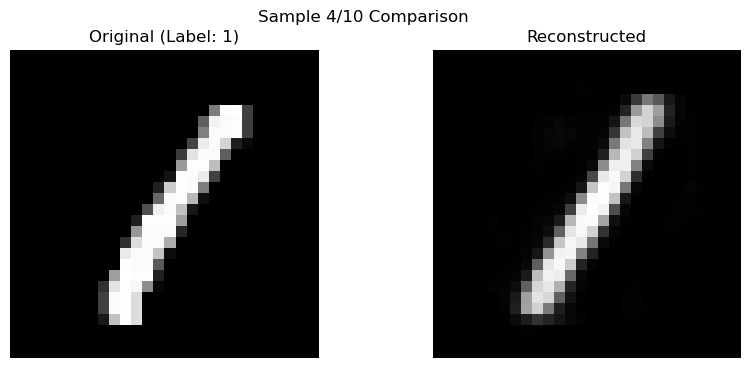

<Figure size 640x480 with 0 Axes>

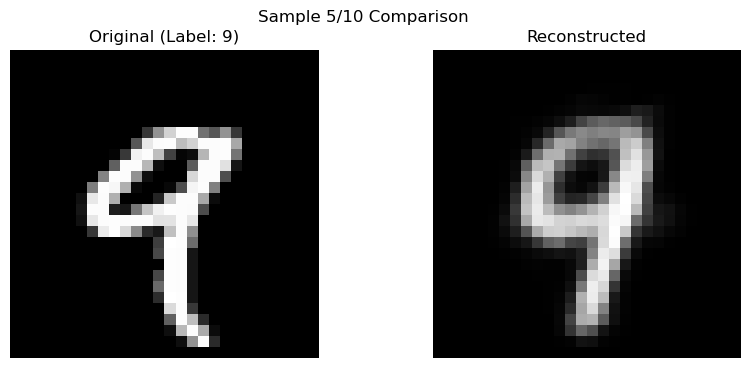

<Figure size 640x480 with 0 Axes>

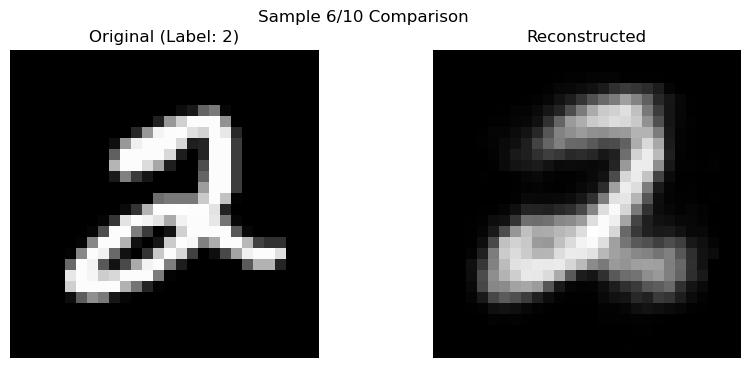

<Figure size 640x480 with 0 Axes>

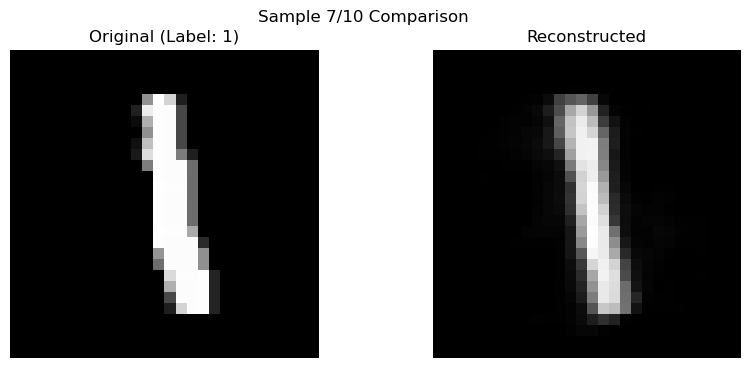

<Figure size 640x480 with 0 Axes>

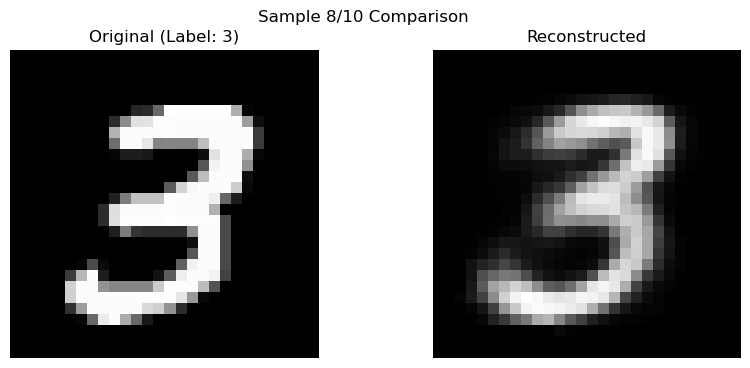

<Figure size 640x480 with 0 Axes>

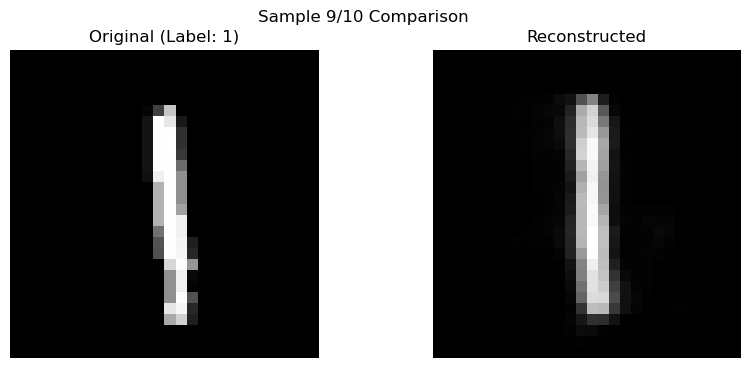

<Figure size 640x480 with 0 Axes>

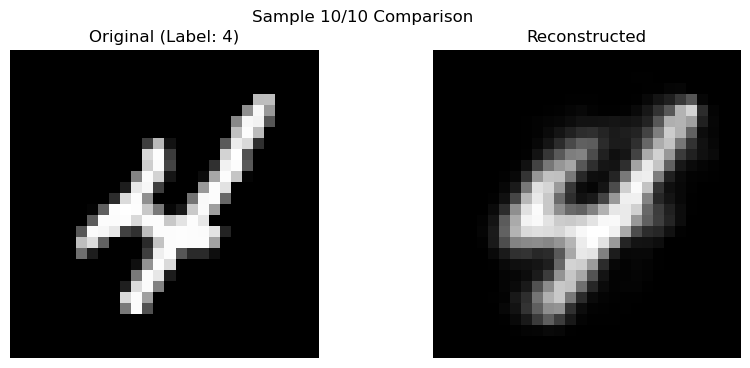

<Figure size 640x480 with 0 Axes>

In [8]:
# 原数据和生成数据的比较（动态可视化）
plt.ion()  # 开启交互模式
plt.show()

for i in range(10):  # 比较前10个样本
    # 准备测试数据
    test_data = train_data.train_data[i].view(-1, 28*28).type(torch.FloatTensor)/255.  # 归一化
    
    # 通过自动编码器生成重建图像
    _, reconstructed = Coder(test_data)  # 注意接收两个返回值
    
    # 转换为图像格式
    im_reconstructed = reconstructed.view(28, 28)
    
    # 创建对比图
    plt.figure(figsize=(10, 4))
    
    # 原始图像
    plt.subplot(1, 2, 1)
    plt.imshow(train_data.train_data[i].numpy(), cmap='gray')
    plt.title(f'Original (Label: {train_data.train_labels[i].item()})')
    plt.axis('off')
    
    # 重建图像
    plt.subplot(1, 2, 2)
    plt.imshow(im_reconstructed.detach().numpy(), cmap='gray')
    plt.title('Reconstructed')
    plt.axis('off')
    
    plt.suptitle(f'Sample {i+1}/10 Comparison')
    plt.draw()
    plt.pause(0.8)  # 显示时长（秒）
    plt.clf()  # 清除当前图形

plt.ioff()  # 关闭交互模式
plt.show()  # 保持最终图像显示